In [1]:
import os
import torch
from transformers import AutoConfig, LlamaWithRetrievalHeadAndKnowledgeInjectorForCausalLM, AutoTokenizer


/liuzyai04/thuir/dongqian/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%cd src
from utils import freeze_non_crossattention_parameters,print_trainable_params_stats

/liuzyai04/thuir/dongqian/code/ReGPT/src


/liuzyai04/thuir/dongqian/.local/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# from transformers import AutoConfig, Qwen2WithRetrievalHeadAndKnowledgeInjectorForCausalLM, AutoTokenizer
model_path = '../../llama3-chat'
config = AutoConfig.from_pretrained(model_path)
config.kg_model_name_or_path = './output/'
config.cross_attention_activation_function = 'silu'
config.add_cross_attention = True
config.add_cross_attention_layer_number = 31
config.faiss_dimension = 4096

model = LlamaWithRetrievalHeadAndKnowledgeInjectorForCausalLM.from_pretrained(model_path, config=config, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading checkpoint shards: 100%|██████████| 4/4 [00:09<00:00,  2.43s/it]
Some weights of LlamaWithRetrievalHeadAndKnowledgeInjectorForCausalLM were not initialized from the model checkpoint at ../../llama3-chat and are newly initialized: ['model.layers.0.gate_crossattention.W_A', 'model.layers.0.gate_crossattention.W_B', 'model.layers.1.gate_crossattention.W_A', 'model.layers.1.gate_crossattention.W_B', 'model.layers.10.gate_crossattention.W_A', 'model.layers.10.gate_crossattention.W_B', 'model.layers.11.gate_crossattention.W_A', 'model.layers.11.gate_crossattention.W_B', 'model.layers.12.gate_crossattention.W_A', 'model.layers.12.gate_crossattention.W_B', 'model.layers.13.gate_crossattention.W_A', 'model.layers.13.gate_crossattention.W_B', 'model.layers.14.gate_crossattention.W_A', 'model.layers.14.gate_crossattention.W_B', 'model.layers.15.gate_crossattention.W_A', 'model.layers.15.gate_crossattention.W_B', 'model.layers.16.gate_crossattention.W_A', 'model.layers.16.gate_crossattenti

In [4]:
from calflops import calculate_flops

In [5]:
model = model.half()
model.to('cuda:6')
model.eval()
print('loaded in cuda')

loaded in cuda


In [13]:
import time
import torch
def convert_to_tflops(flops_str):
    """将GFLOPS或TFLOPS字符串转换为TFLOPS的浮点数"""
    value = float(flops_str.split()[0])
    if 'GFLOPS' in flops_str:
        return value / 1000  # 转换GFLOPS为TFLOPS
    return value  # 已经是TFLOPS

def calculate_model_metrics(model, tokenizer, input_text, num_knowledge=4, mode="Online DecoupledRAG", device='cuda:6'):
    """
    计算模型的FLOPs、MACs和参数数量
    
    Args:
        model: 要评估的模型
        tokenizer: 分词器
        input_text: 输入文本
        num_knowledge: 知识条目的数量或知识长度倍数
        mode: "Online DecoupledRAG"/"Offline DecoupledRAG"/"VanillaRAG" 表示知识的组织方式
        device: 计算设备
    """    
    # 准备输入
    inputs = {}
    if mode == "Online DecoupledRAG":
        # 分离的知识表示
        knowledge = ['The '*256 for i in range(num_knowledge)]
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids
        knowledge_input_ids = tokenizer(knowledge, return_tensors="pt").input_ids
        
        inputs["input_ids"] = input_ids
        inputs["knowledge_input_ids"] = knowledge_input_ids

    elif mode == "Offline DecoupledRAG":
        # 预计算知识表示
        knowledge = ['The '*256 for i in range(num_knowledge)]
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids
        knowledge_input_ids = tokenizer(knowledge, return_tensors="pt").input_ids
        
        # 预计算知识输出
        with torch.no_grad():
            knowledge_outputs = model(
                input_ids=knowledge_input_ids.to(device),
                output_hidden_states=True,
                return_dict=True,
            ).hidden_states
            
            knowledge_outputs = torch.stack(knowledge_outputs)
        
        inputs["input_ids"] = input_ids
        inputs["knowledge_outputs"] = knowledge_outputs
    
    else:  # concatenated
        # 连接的知识表示
        knowledge = 'The '*(256 * num_knowledge)
        full_text = input_text + knowledge
        input_ids = tokenizer(full_text, return_tensors="pt").input_ids
        
        inputs["input_ids"] = input_ids
    
    start = time.time()
    # 计算指标
    with torch.no_grad():
        flops, macs, params = calculate_flops(model=model,
                                            kwargs=inputs,
                                            print_results=False)
    runing_time = time.time() - start
    flops = convert_to_tflops(flops)
    return flops, macs, params, runing_time



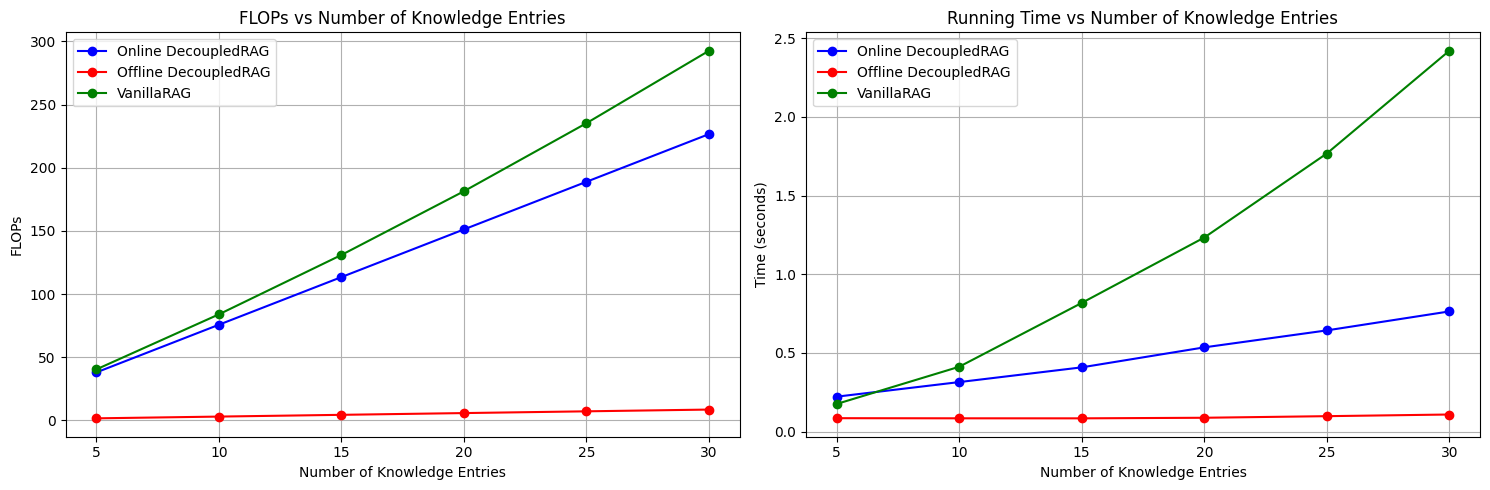


Detailed Results:

Online DecoupledRAG:
FLOPs: [37.89, 75.65, 113.4, 151.16, 188.91, 226.67]
Time: [0.22230887413024902, 0.3149840831756592, 0.4085855484008789, 0.5355403423309326, 0.6433565616607666, 0.7639024257659912]

Offline DecoupledRAG:
FLOPs: [1.53, 2.92, 4.31, 5.7, 7.09, 8.48]
Time: [0.08572697639465332, 0.0849156379699707, 0.0847318172454834, 0.08842134475708008, 0.09852933883666992, 0.10908126831054688]

VanillaRAG:
FLOPs: [40.28, 83.88, 130.92, 181.4, 235.33, 292.7]
Time: [0.17592453956604004, 0.4122757911682129, 0.8177917003631592, 1.2331585884094238, 1.7669506072998047, 2.4199249744415283]


In [15]:
import time
import torch
import matplotlib.pyplot as plt
import numpy as np

# 存储结果的数据结构
results = {
    'Online DecoupledRAG': {'flops': [], 'time': []},
    'Offline DecoupledRAG': {'flops': [], 'time': []},
    'VanillaRAG': {'flops': [], 'time': []}
}

knowledge_range = range(5, 31, 5)

for num_knowledge in knowledge_range:
    input_text = 'Your question.'
    
    # Online DecoupledRAG
    metrics = calculate_model_metrics(model, tokenizer, input_text, 
                                   num_knowledge=num_knowledge, 
                                   mode="Online DecoupledRAG")
    results['Online DecoupledRAG']['flops'].append(metrics[0])
    results['Online DecoupledRAG']['time'].append(metrics[-1])
    
    # Offline DecoupledRAG
    metrics = calculate_model_metrics(model, tokenizer, input_text, 
                                   num_knowledge=num_knowledge, 
                                   mode="Offline DecoupledRAG")
    results['Offline DecoupledRAG']['flops'].append(metrics[0])
    results['Offline DecoupledRAG']['time'].append(metrics[-1])
    
    # VanillaRAG
    start_time = time.time()
    metrics = calculate_model_metrics(model, tokenizer, input_text, 
                                   num_knowledge=num_knowledge, 
                                   mode="VanillaRAG")
    results['VanillaRAG']['flops'].append(metrics[0])
    results['VanillaRAG']['time'].append(metrics[-1])

# 绘图
plt.figure(figsize=(15, 5))
colors = {'Online DecoupledRAG': 'blue', 
          'Offline DecoupledRAG': 'red', 
          'VanillaRAG': 'green'}

# FLOPs图
plt.subplot(1, 2, 1)
for mode in results.keys():
    plt.plot(list(knowledge_range), results[mode]['flops'], 
             label=mode, color=colors[mode], marker='o')
plt.xlabel('Number of Knowledge Entries')
plt.ylabel('FLOPs')
plt.title('FLOPs vs Number of Knowledge Entries')
plt.grid(True)
plt.legend()

# Time图
plt.subplot(1, 2, 2)
for mode in results.keys():
    plt.plot(list(knowledge_range), results[mode]['time'], 
             label=mode, color=colors[mode], marker='o')
plt.xlabel('Number of Knowledge Entries')
plt.ylabel('Time (seconds)')
plt.title('Running Time vs Number of Knowledge Entries')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印具体数值
print("\nDetailed Results:")
for mode in results.keys():
    print(f"\n{mode}:")
    print(f"FLOPs: {results[mode]['flops']}")
    print(f"Time: {results[mode]['time']}")

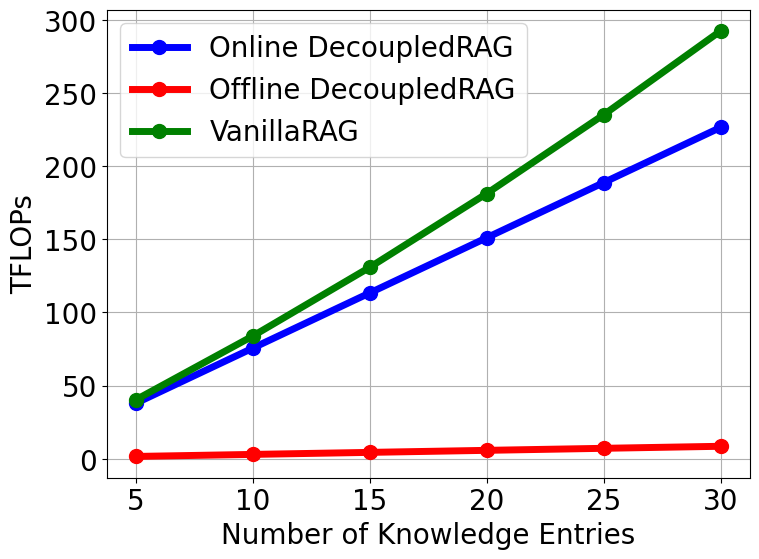

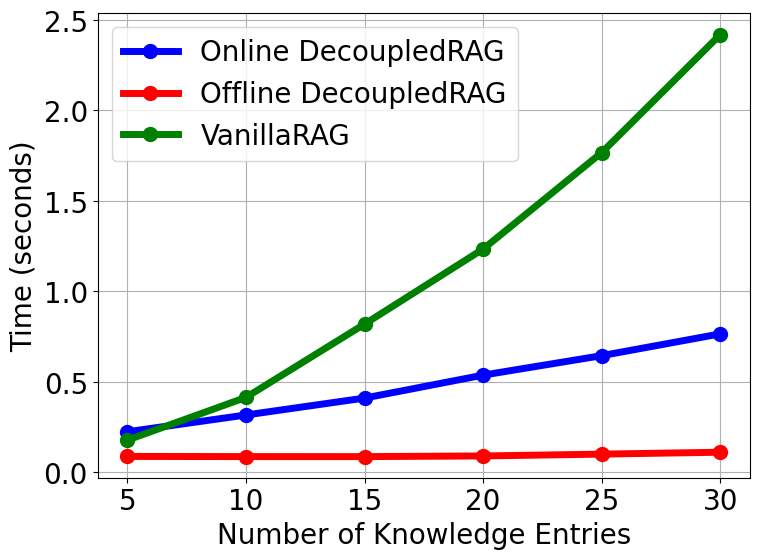

In [27]:
# 设置全局字体大小
plt.rcParams.update({'font.size': 20})

colors = {'Online DecoupledRAG': 'blue', 
          'Offline DecoupledRAG': 'red', 
          'VanillaRAG': 'green'}

# FLOPs图
plt.figure(figsize=(8, 6))
for mode in results.keys():
    plt.plot(list(knowledge_range), results[mode]['flops'], 
             label=mode, color=colors[mode], marker='o', linewidth=5,  # 增加线的粗细
             markersize=10)  # 增加标记点的大小

plt.xlabel('Number of Knowledge Entries')
plt.ylabel('TFLOPs')
plt.grid(True)
plt.legend()
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.savefig('flops_comparison.pdf', bbox_inches='tight')  # 保存为PDF
plt.show()

# Time图
plt.figure(figsize=(8, 6))
for mode in results.keys():
    plt.plot(list(knowledge_range), results[mode]['time'], 
             label=mode, color=colors[mode], marker='o',linewidth=5,  # 增加线的粗细
             markersize=10)  # 增加标记点的大小
plt.xlabel('Number of Knowledge Entries')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.legend()
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.savefig('time_comparison.pdf', bbox_inches='tight')  # 保存为PDF
plt.show()
